# Fase 1: Diagnóstico Inicial

Todo gran proyecto de Ciencia de Datos aplicados a la agricultura comienza con una pregunta fundamental: *¿Cómo se comportan nuestros cultivos en el espacio y el tiempo?* 

En esta primera etapa, prepararemos nuestro entorno de trabajo e importaremos las mediciones recolectadas en campo. Nuestro objetivo inmediato es realizar un "diagnóstico" para entender la estructura, dimensiones y tipos de datos con los que estamos lidiando antes de entrenar cualquier modelo predictivo.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Carga de la base de datos
df = pd.read_csv("DATA SET CSV.csv")

# Inspección inicial del estado de los datos
print("--- PRIMEROS REGISTROS ---")
print(df.head())
print("\n--- ESTRUCTURA Y TIPOS DE DATOS ---")
print(df.info())
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(df.describe())

--- PRIMEROS REGISTROS ---
             ID            x            y  edad_aprox  ndvi_media  ndvi_max  \
0  AGROSILV_001  569648.9219  2206002.619          10    0.681852  0.881289   
1  AGROSILV_002  569648.5976  2206000.348          10    0.682127  0.922071   
2  AGROSILV_003  569648.0896  2205997.971          10    0.666949  0.872402   
3  AGROSILV_004  569647.5716  2205995.588          10    0.631413  0.842249   
4  AGROSILV_005  569647.1305  2205993.296          10    0.678549  0.953309   

   ndvi_std  gndvi_media  ndre_media  ndre_std  savi_media  savi_std  area_m2  \
0  0.136940     0.393516    0.084521  0.078242    1.022775  0.205367    2.059   
1  0.113145     0.368540    0.065847  0.091895    1.023393  0.169441    3.626   
2  0.114971     0.348688    0.055619  0.084720    1.000318  0.172235    3.450   
3  0.157529     0.317238    0.045486  0.076575    0.946976  0.237027    1.259   
4  0.130447     0.345647    0.048250  0.093811    1.017619  0.196019    3.496   

   perimetr

# Análisis de Distribución y el "Ritmo" de las Variables

Para evitar sorpresas o sesgos más adelante, necesitamos ver la fotografía completa. ¿Nuestros datos siguen una distribución normal? ¿Hay valores atípicos (outliers) en las alturas o en las áreas de los predios? 

Visualizar el histograma de cada variable numérica nos permite entender el comportamiento global de las mediciones de campo y los índices de vegetación de manera simultánea.

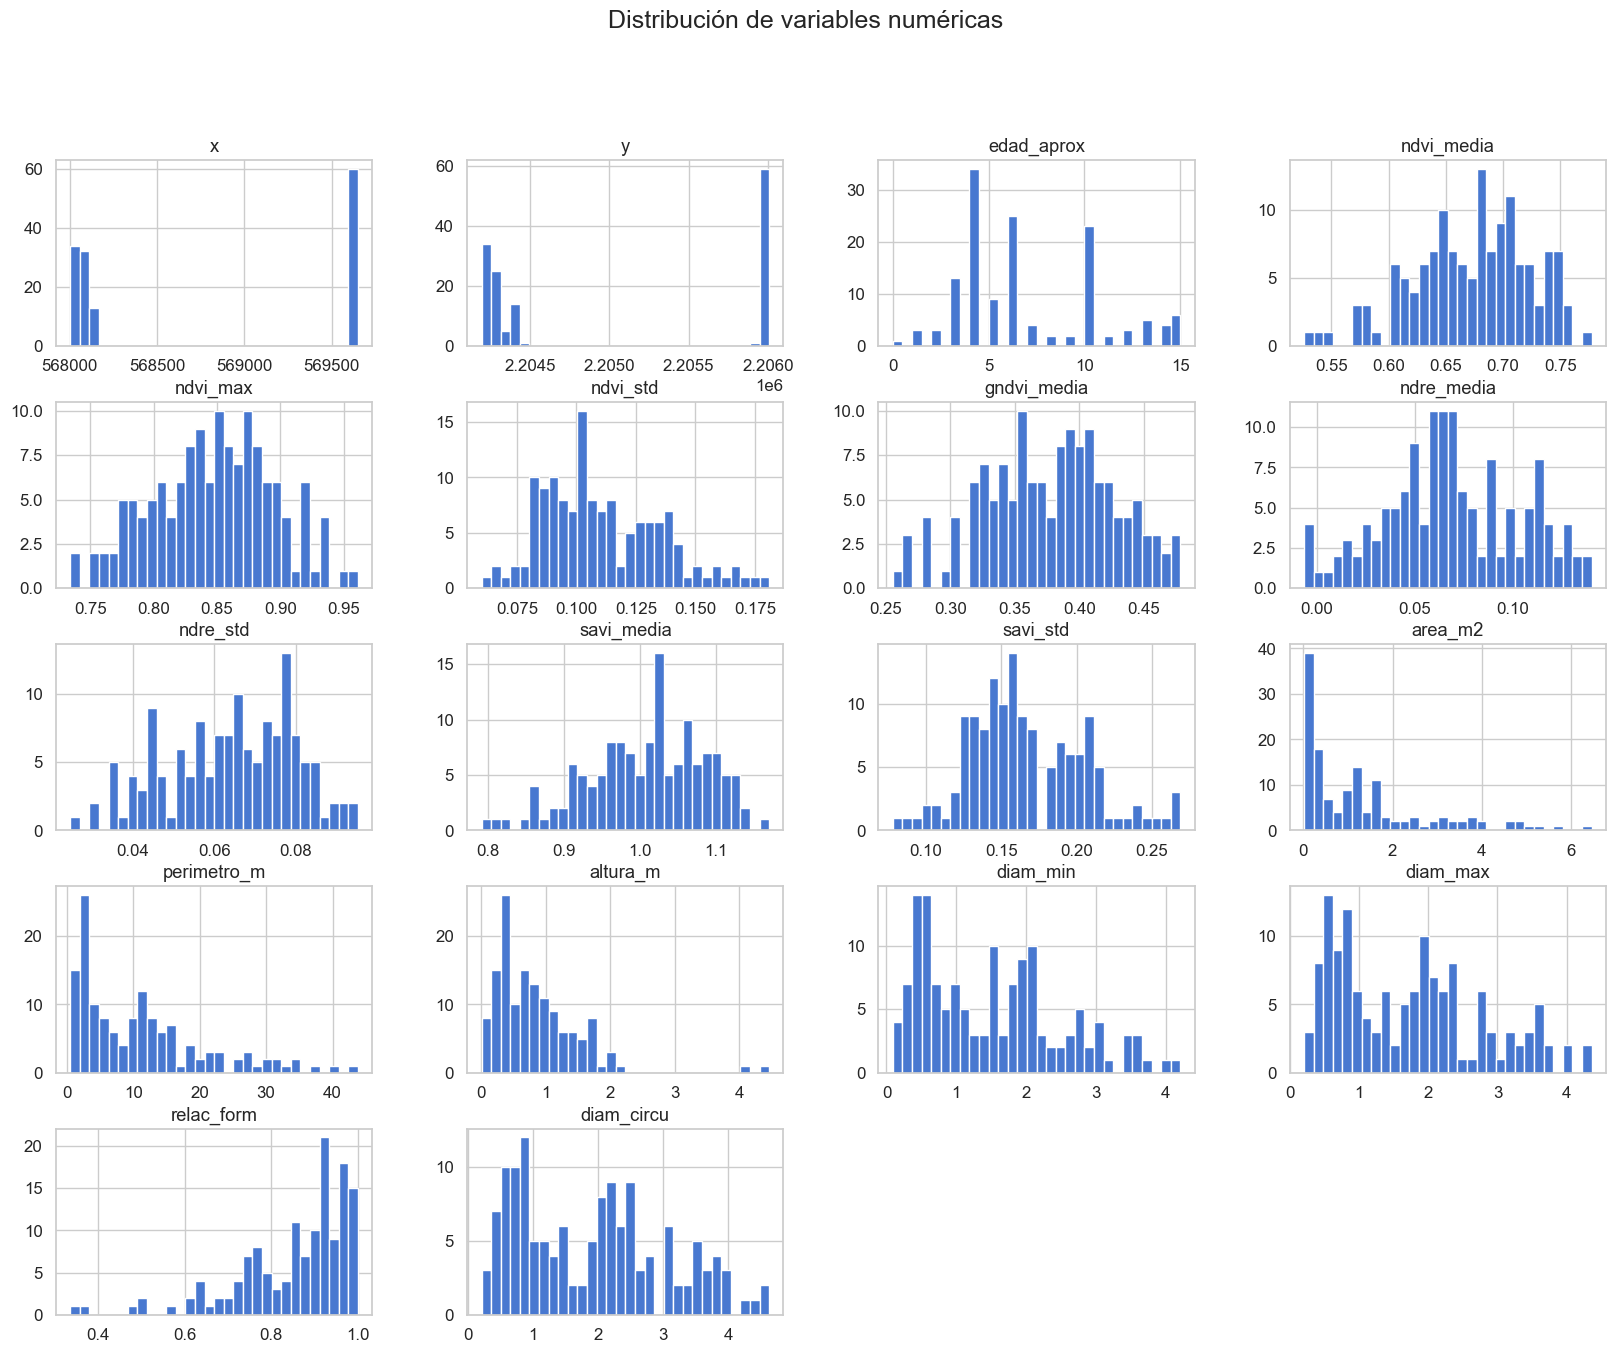

In [18]:
# Aislamiento de variables numéricas para análisis gráfico
num_cols = df.select_dtypes(include=[np.number]).columns

# Renderizado de histogramas globales
df[num_cols].hist(figsize=(20, 15), bins=30)
plt.suptitle("Distribución de variables numéricas", fontsize=18)
plt.show()

# Mapeo de Sinergias (Matriz de Correlación)

Las variables en la naturaleza rara vez actúan solas; suelen moverse juntas. En esta fase, utilizaremos una **Matriz de Correlación** para descubrir qué variables numéricas están fuertemente vinculadas. 

Buscamos responder preguntas clave: *¿El NDVI sube o baja a medida que la planta envejece? ¿La altura del cultivo está directamente relacionada con su respuesta espectral?* Esto nos guiará para seleccionar las mejores características (features) para el modelado.

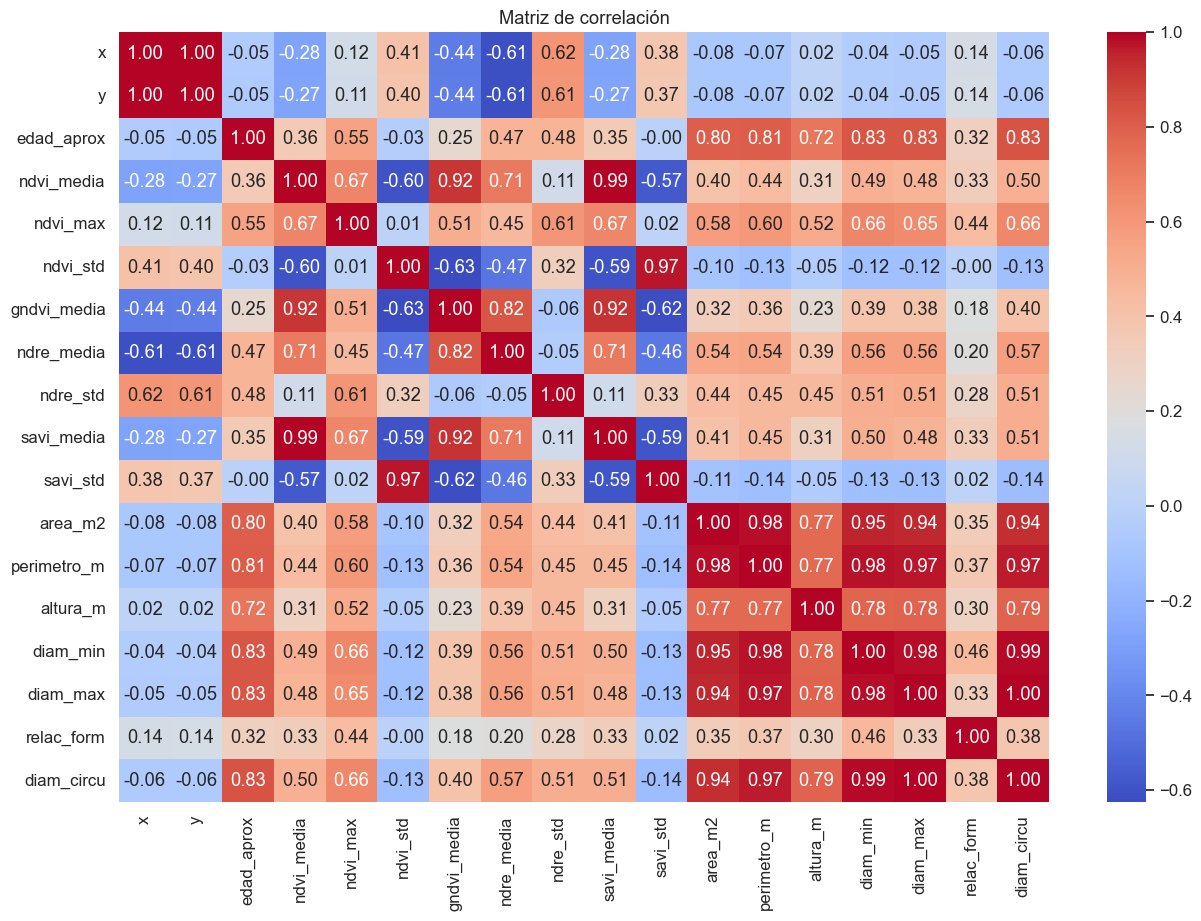

In [21]:
# Cálculo y visualización de la matriz de correlación lineal
plt.figure(figsize=(15, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# Zoom Científico – Edad vs. Índices Multiespectrales

Los índices de vegetación (`NDVI`, `GNDVI`, `NDRE`, `SAVI`) son nuestra ventana hacia la salud fotosintética del cultivo. Sin embargo, para que sean útiles, necesitamos ver cómo cambian individualmente a lo largo de la vida de la planta (`edad_aprox`) y si este comportamiento varía según el **predio** geográfico donde se encuentran. 

Utilizaremos diagramas de dispersión y un análisis de pares (`pairplot`) para buscar tendencias, agrupaciones naturales o patrones no lineales entre la edad, el área y el vigor vegetal.

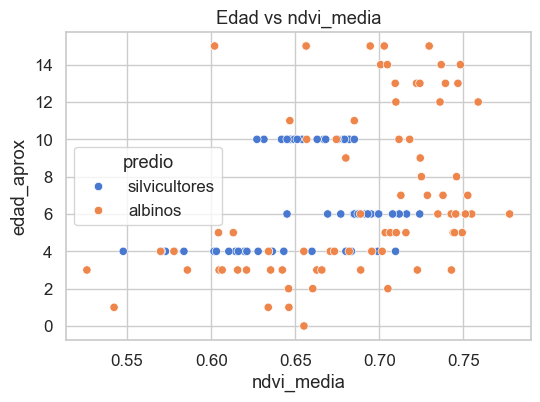

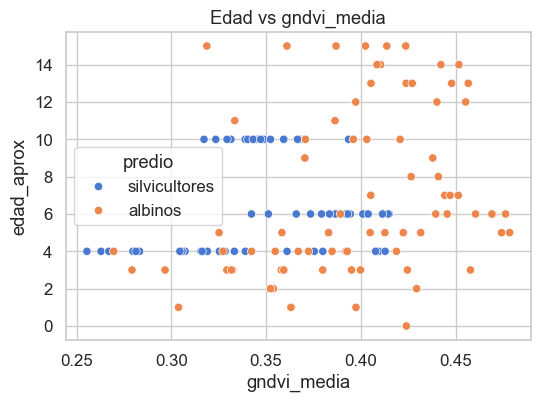

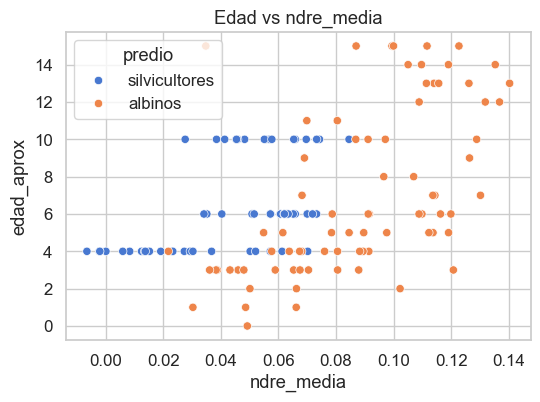

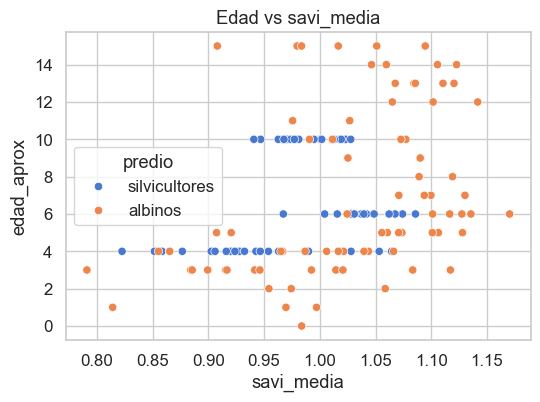

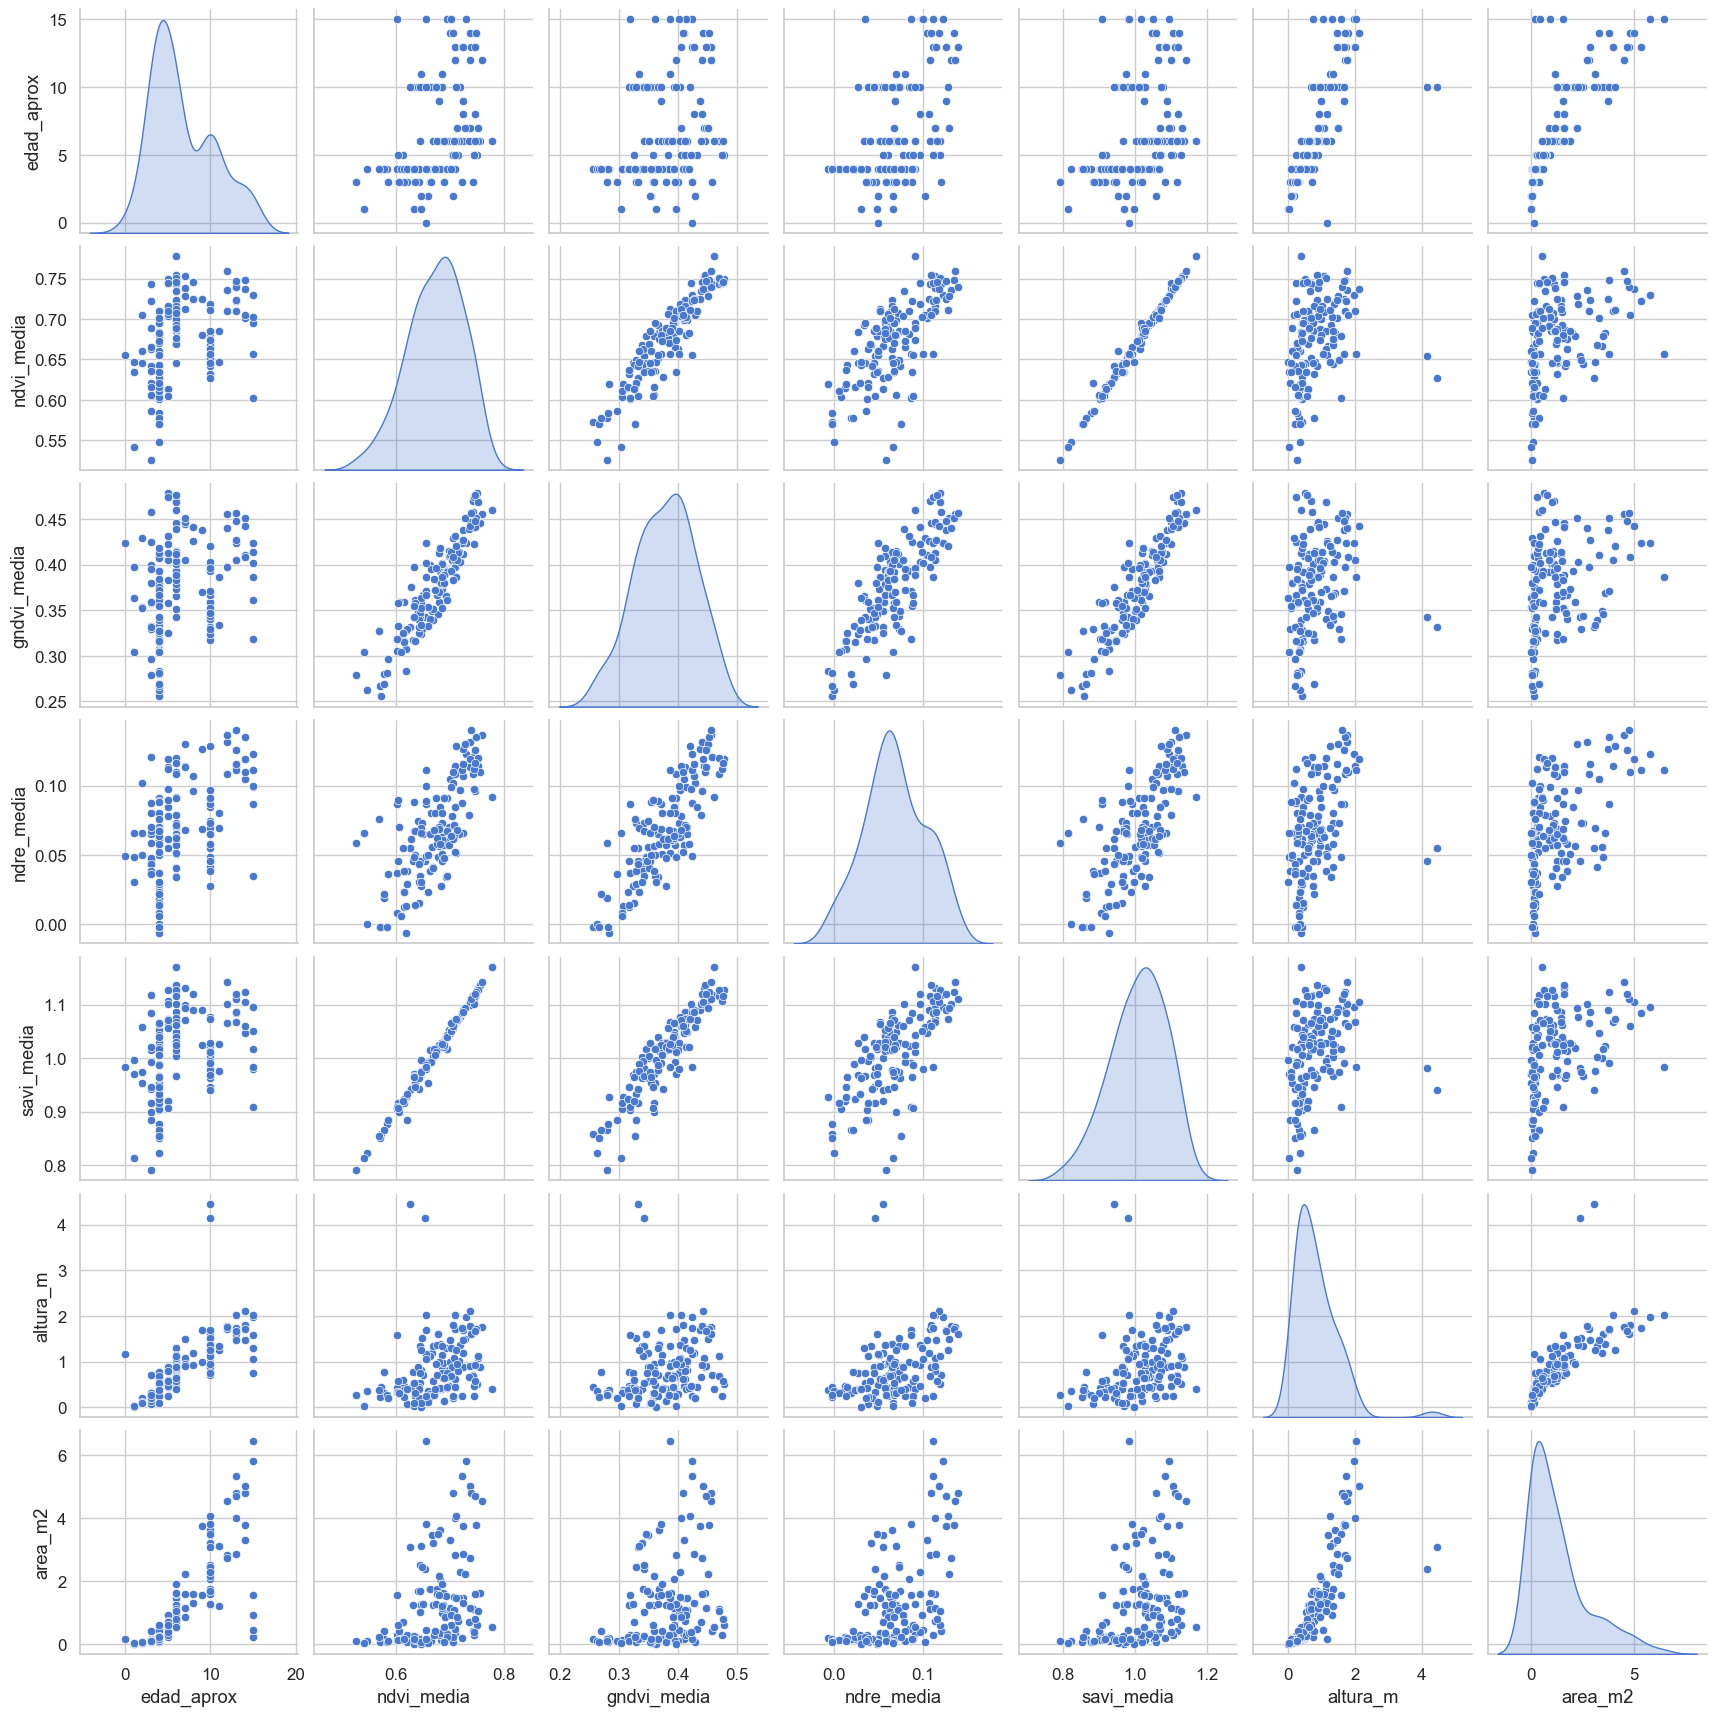

In [25]:
# Análisis de dispersión individual por cada índice clave
indices = ["ndvi_media", "gndvi_media", "ndre_media", "savi_media"]
for col in indices:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["edad_aprox"], hue=df["predio"])
    plt.title(f"Edad vs {col}")
    plt.show()

# Vista holística de interacciones clave entre las variables principales
selected_cols = ["edad_aprox","ndvi_media","gndvi_media","ndre_media","savi_media","altura_m","area_m2"]
sns.pairplot(df[selected_cols], diag_kind="kde")
plt.show()

# Agrupación por Etapas Cronológicas (Análisis de Cajas)

Analizar la edad como un número continuo puede ocultar los cambios drásticos que ocurren entre etapas de desarrollo (p. ej. juventud vs. madurez del cultivo). 

Para resolver esto, **categorizaremos la edad en bloques de desarrollo de 5 años**. Al contrastar estos grupos con nuestros índices de vegetación mediante diagramas de caja (*Boxplots*), podremos ver con claridad matemática si el vigor vegetal disminuye de manera escalonada a medida que el cultivo avanza en su ciclo de vida.

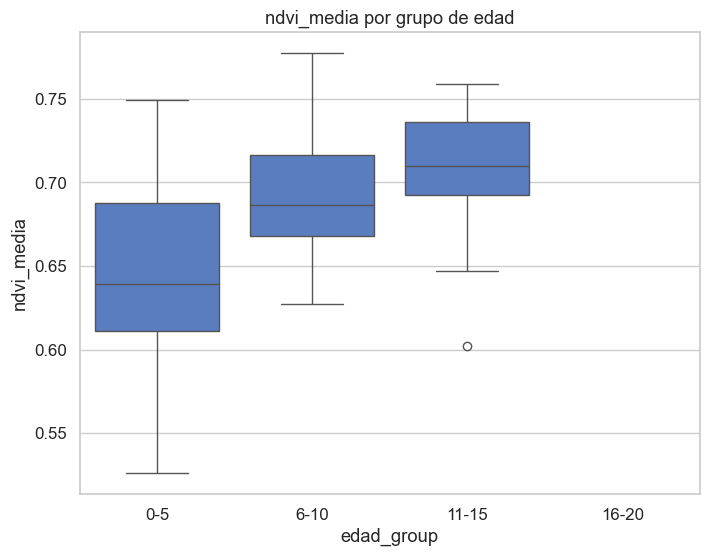

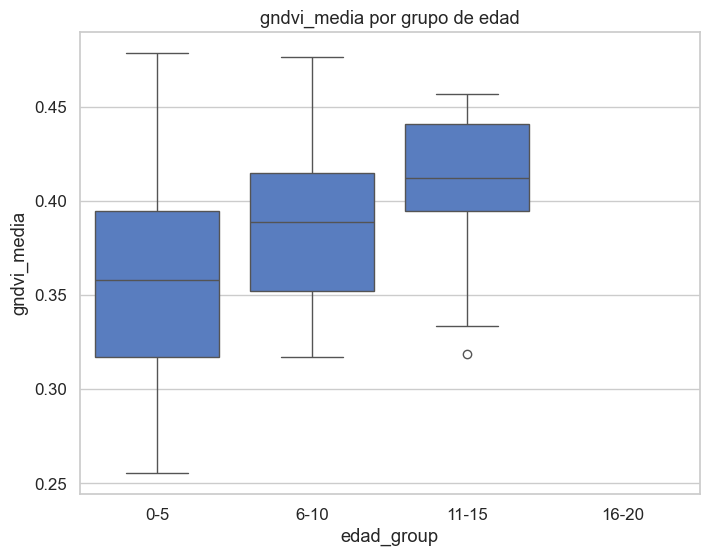

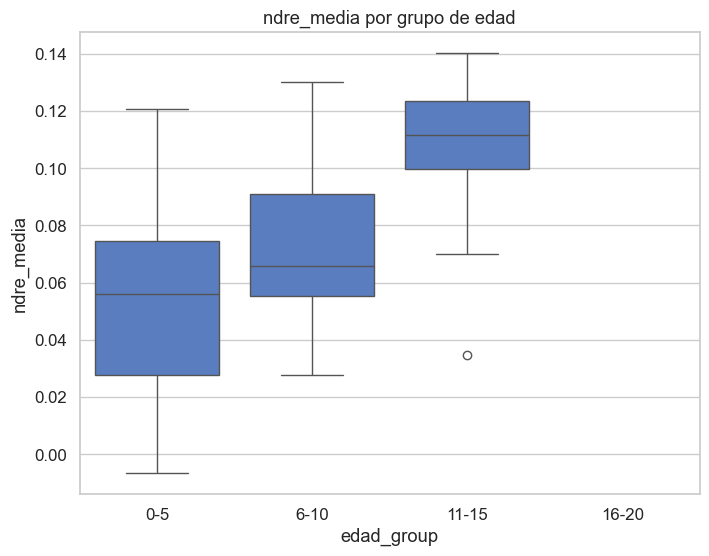

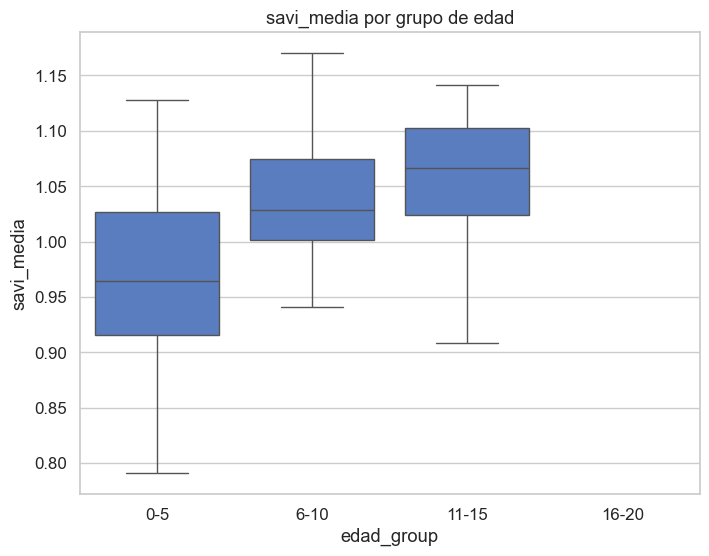

In [28]:
# Transformación de variable continua a rangos categóricos de edad
df["edad_group"] = pd.cut(df["edad_aprox"], bins=[0,5,10,15,20], labels=["0-5","6-10","11-15","16-20"])

# Evaluación del comportamiento de los índices en cada etapa cronológica
for col in indices:
    plt.figure(figsize=(8,6))
    sns.boxplot(x="edad_group", y=col, data=df)
    plt.title(f"{col} por grupo de edad")
    plt.show()

# Análisis de Contexto – El Impacto del Terreno (Predios)

Para cerrar nuestra exploración, debemos reconocer que la tierra importa. Dos plantas de la misma edad pueden comportarse diferente según el suelo o el microclima de su parcela. 

En esta sección final, analizaremos la distribución de registros disponibles por cada predio y evaluaremos directamente el comportamiento del `NDVI` entre los diferentes terrenos. Esto nos confirmará si el "Predio" es una variable crítica que el modelo predictivo debe aprender a diferenciar obligatoriamente.


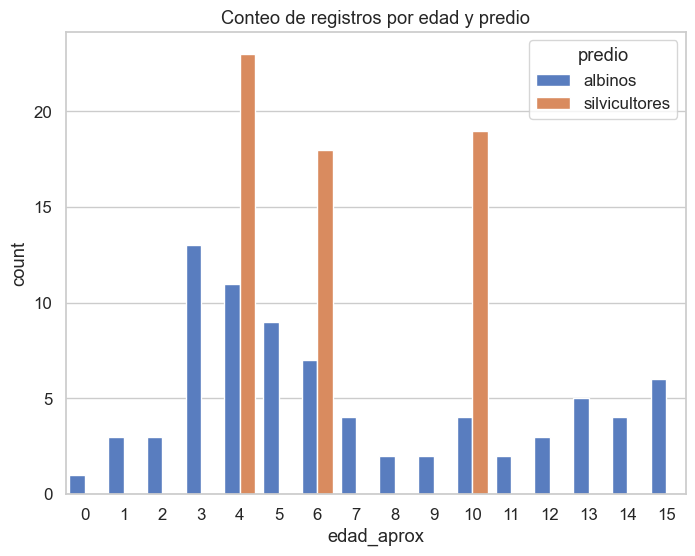

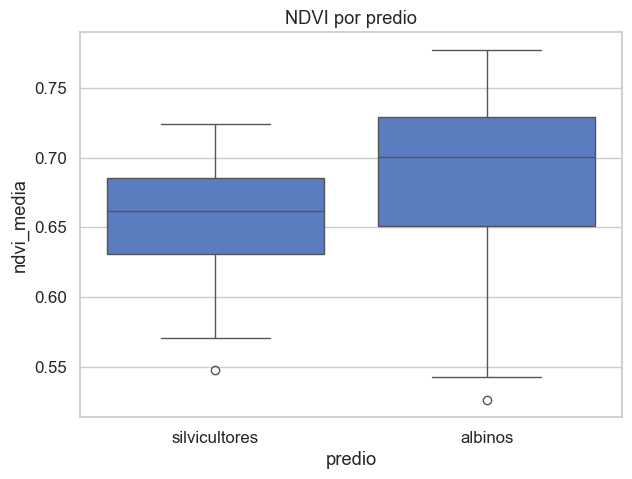

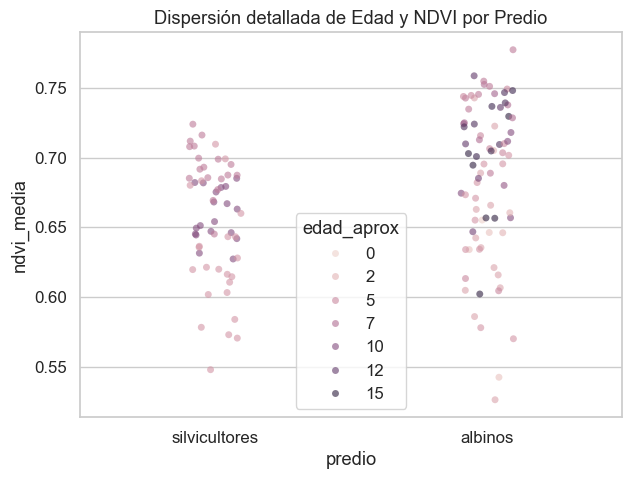

In [33]:
# Distribución demográfica de los datos por ubicación y edad
plt.figure(figsize=(8,6))
sns.countplot(x="edad_aprox", data=df, hue="predio")
plt.title("Conteo de registros por edad y predio")
plt.show()

# Comparación del comportamiento del vigor vegetal (NDVI) entre terrenos
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="predio", y="ndvi_media")
plt.title("NDVI por predio")
plt.show()

# Micro-análisis de distribución de edades individuales dentro de la firma de NDVI por predio
plt.figure(figsize=(7,5))
sns.stripplot(data=df, x="predio", y="ndvi_media", hue="edad_aprox", dodge=False, alpha=0.6)
plt.title("Dispersión detallada de Edad y NDVI por Predio")
plt.show()

## Conclusión del Análisis Exploratorio (EDA)
Hemos transformado filas de datos crudos en conocimiento accionable. Descubrimos cómo interactúan los índices multiespectrales con el paso del tiempo y confirmamos que las condiciones varían según el predio analizado. 

Con estos insights validados y la certeza de que existe una relación clara entre la respuesta espectral y la edad del cultivo, **estamos listos para proceder a la fase de Modelado Predictivo**.